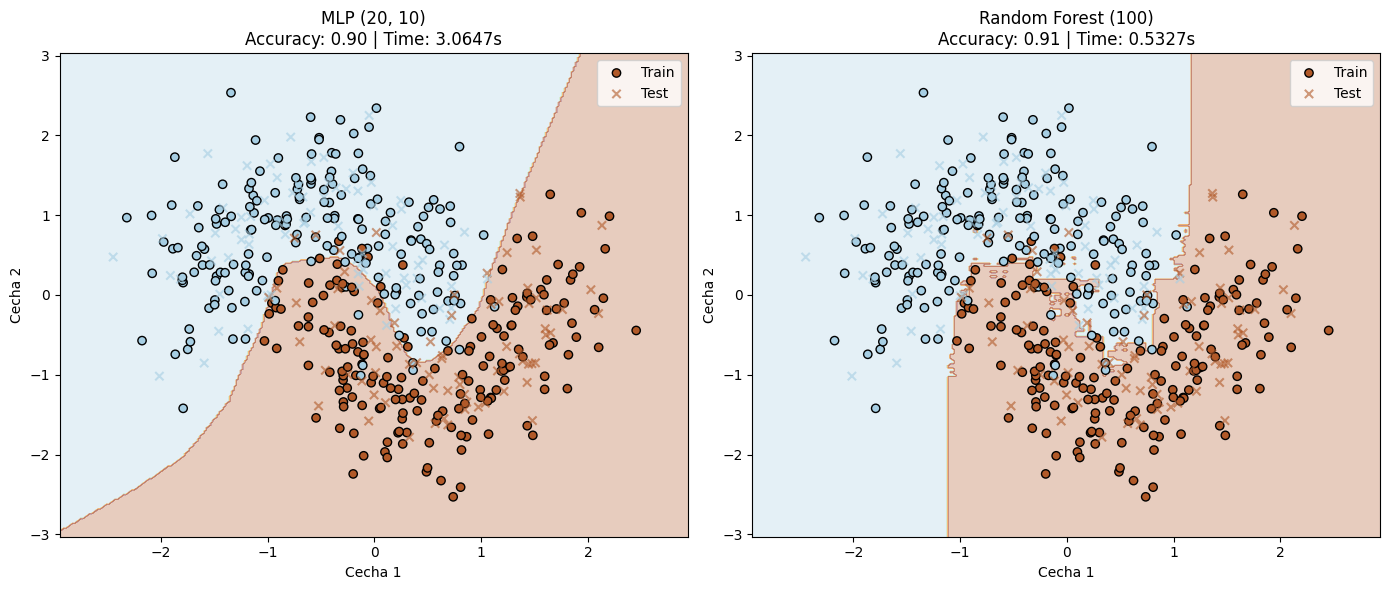


=== PORÓWNANIE MODELI ===
MLP (20, 10)         -> Accuracy: 0.9000, Czas treningu: 3.0647 sekund
Random Forest (100)  -> Accuracy: 0.9067, Czas treningu: 0.5327 sekund


In [9]:
# Porownaj granice decyzyjne MLP i Random Forest na syntetycznych danych.
# Wymagania:
# Wygeneruj make_moons(n_samples=500, noise=0.3)
# Wytrenuj MLP (20, 10) i Random Forest (100 drzew)
# Narysuj granice decyzyjne obu modeli obok siebie
# Porownaj accuracy, czas treningu
# Oczekiwany wynik:
# 2 wykresy granic decyzyjnych i porownanie metryk

import time
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_moons
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler

# Wygenerowanie danych zgodnie z wymaganiami z komentarza
X, y = make_moons(n_samples=500, noise=0.3, random_state=42)

# Skalowanie danych (bardzo ważne dla sieci neuronowych MLP!)
X = StandardScaler().fit_transform(X)

# Podział na zbiór treningowy i testowy (bez tego pętla nie zadziała)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Definicja modeli z wymaganymi parametrami
models = {
    "MLP (20, 10)": MLPClassifier(
        hidden_layer_sizes=(20, 10), max_iter=1000, random_state=42
    ),
    "Random Forest (100)": RandomForestClassifier(
        n_estimators=100, random_state=42
    ),
}

# Słowniki na wyniki
metrics = {}

# Siatka do rysowania granic decyzyjnych (Meshgrid) - teraz używa poprawnej zmiennej X
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))

# Przygotowanie wykresu (2 wykresy obok siebie)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, (name, model) in zip(axes, models.items()):
    # Pomiar czasu treningu
    start_time = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start_time

    # Predykcja i dokładność (Accuracy)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    # Zapisanie metryk do wyświetlenia
    metrics[name] = {"Accuracy": acc, "Train Time (s)": train_time}

    # Rysowanie granicy decyzyjnej
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Paired)

    # Rysowanie punktów treningowych i testowych
    ax.scatter(
        X_train[:, 0],
        X_train[:, 1],
        c=y_train,
        edgecolors="k",
        cmap=plt.cm.Paired,
        label="Train",
    )
    ax.scatter(
        X_test[:, 0],
        X_test[:, 1],
        c=y_test,
        marker="x",
        cmap=plt.cm.Paired,
        alpha=0.6,
        label="Test",
    )

    ax.set_title(f"{name}\nAccuracy: {acc:.2f} | Time: {train_time:.4f}s")
    ax.set_xlabel("Cecha 1")
    ax.set_ylabel("Cecha 2")
    ax.legend()

plt.tight_layout()
plt.show()

# 3. Wypisanie porównania metryk w konsoli
print("\n=== PORÓWNANIE MODELI ===")
for name, results in metrics.items():
    print(
        f"{name:20} -> Accuracy: {results['Accuracy']:.4f}, Czas treningu: {results['Train Time (s)']:.4f} sekund"
    )